In [13]:
!pip install -q kaggle

In [14]:
from google.colab import files

uploaded = files.upload()

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage' dataset.
Path to dataset files: /kaggle/input/plantvillage


In [16]:
!kaggle datasets download -d mohitsingh1804/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:06<00:00, 138MB/s]



In [17]:
!unzip -q plantvillage.zip -d /content/PlantVillage

In [18]:
!ls -lah /content/PlantVillage

total 12K
drwxr-xr-x 3 root root 4.0K Sep 22 12:21 .
drwxr-xr-x 1 root root 4.0K Sep 22 12:21 ..
drwxr-xr-x 4 root root 4.0K Sep 22 12:21 PlantVillage


In [19]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("TFDS:", getattr(tfds, "__version__", "version unavailable"))
print("Protobuf import: successful")
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
TFDS: version unavailable
Protobuf import: successful
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:

import os
import random
import zipfile
import time
import json
import shutil

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Environment ready")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Environment ready


In [22]:

zip_path = Path("/content/plantvillage.zip")
extract_dir = Path("/content/plantvillage_data")

if not zip_path.exists():
    raise FileNotFoundError(
        f"Dataset ZIP not found: {zip_path}"
    )

extract_dir.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted successfully")
print("Extraction directory:", extract_dir)

Dataset extracted successfully
Extraction directory: /content/plantvillage_data


In [23]:

for root, dirs, files in os.walk(extract_dir):
    level = Path(root).relative_to(extract_dir).parts
    indent = "  " * len(level)

    print(f"{indent}{Path(root).name}/")

    if len(level) >= 3:
        dirs[:] = []

print("\nTop-level contents:")
for item in extract_dir.iterdir():
    print(item)

plantvillage_data/
  PlantVillage/
    train/
      Potato___Late_blight/
      Soybean___healthy/
      Strawberry___healthy/
      Tomato___Tomato_mosaic_virus/
      Tomato___Leaf_Mold/
      Raspberry___healthy/
      Tomato___Bacterial_spot/
      Peach___Bacterial_spot/
      Grape___Black_rot/
      Cherry_(including_sour)___healthy/
      Corn_(maize)___Northern_Leaf_Blight/
      Potato___healthy/
      Orange___Haunglongbing_(Citrus_greening)/
      Blueberry___healthy/
      Tomato___Spider_mites Two-spotted_spider_mite/
      Potato___Early_blight/
      Tomato___Early_blight/
      Grape___Esca_(Black_Measles)/
      Apple___healthy/
      Corn_(maize)___Common_rust_/
      Cherry_(including_sour)___Powdery_mildew/
      Tomato___Septoria_leaf_spot/
      Pepper,_bell___Bacterial_spot/
      Grape___healthy/
      Corn_(maize)___healthy/
      Apple___Black_rot/
      Squash___Powdery_mildew/
      Tomato___Late_blight/
      Peach___healthy/
      Pepper,_bell___healthy/


In [24]:

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

def count_images(folder):
    return sum(
        1
        for file in folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in image_extensions
    )

def find_class_root(base_dir):
    candidates = []

    for folder in [base_dir] + list(base_dir.rglob("*")):
        if not folder.is_dir():
            continue

        subfolders = [
            item
            for item in folder.iterdir()
            if item.is_dir()
        ]

        valid_subfolders = 0

        for subfolder in subfolders:
            if count_images(subfolder) > 0:
                valid_subfolders += 1

        if valid_subfolders >= 2:
            candidates.append(
                (folder, valid_subfolders)
            )

    if not candidates:
        raise FileNotFoundError(
            "Could not identify class directory. "
            "Inspect the extracted folder structure."
        )

    candidates.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return candidates[0][0]

class_root = find_class_root(extract_dir)

print("Detected class root:", class_root)

class_folders = sorted([
    folder
    for folder in class_root.iterdir()
    if folder.is_dir()
    and count_images(folder) > 0
])

print("Detected classes:", len(class_folders))

for folder in class_folders:
    print(folder.name, count_images(folder))

Detected class root: /content/plantvillage_data/PlantVillage/train
Detected classes: 38
Apple___Apple_scab 504
Apple___Black_rot 496
Apple___Cedar_apple_rust 220
Apple___healthy 1316
Blueberry___healthy 1202
Cherry_(including_sour)___Powdery_mildew 842
Cherry_(including_sour)___healthy 684
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 410
Corn_(maize)___Common_rust_ 953
Corn_(maize)___Northern_Leaf_Blight 788
Corn_(maize)___healthy 929
Grape___Black_rot 944
Grape___Esca_(Black_Measles) 1107
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) 861
Grape___healthy 339
Orange___Haunglongbing_(Citrus_greening) 4405
Peach___Bacterial_spot 1838
Peach___healthy 288
Pepper,_bell___Bacterial_spot 797
Pepper,_bell___healthy 1183
Potato___Early_blight 800
Potato___Late_blight 800
Potato___healthy 121
Raspberry___healthy 297
Soybean___healthy 4072
Squash___Powdery_mildew 1468
Strawberry___Leaf_scorch 887
Strawberry___healthy 364
Tomato___Bacterial_spot 1702
Tomato___Early_blight 800
Tomato___Late_bligh

In [25]:

class_names = [
    folder.name
    for folder in class_folders
]

class_to_index = {
    name: index
    for index, name in enumerate(class_names)
}

records = []

for class_name in class_names:
    class_dir = class_root / class_name

    for image_path in class_dir.iterdir():
        if (
            image_path.is_file()
            and image_path.suffix.lower()
            in image_extensions
        ):
            records.append({
                "filepath": str(image_path),
                "class_name": class_name,
                "label": class_to_index[class_name]
            })

image_df = pd.DataFrame(records)

NUM_CLASSES = len(class_names)
DATASET_SIZE = len(image_df)

print("Total images:", DATASET_SIZE)
print("Number of classes:", NUM_CLASSES)

print("\nFirst five records:")
print(image_df.head())

Total images: 43444
Number of classes: 38

First five records:
                                            filepath          class_name  \
0  /content/plantvillage_data/PlantVillage/train/...  Apple___Apple_scab   
1  /content/plantvillage_data/PlantVillage/train/...  Apple___Apple_scab   
2  /content/plantvillage_data/PlantVillage/train/...  Apple___Apple_scab   
3  /content/plantvillage_data/PlantVillage/train/...  Apple___Apple_scab   
4  /content/plantvillage_data/PlantVillage/train/...  Apple___Apple_scab   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


In [26]:

class_distribution = (
    image_df["class_name"]
    .value_counts()
    .sort_index()
    .reset_index()
)

class_distribution.columns = [
    "Class Name",
    "Image Count"
]

print(class_distribution.to_string(index=False))

print("\nMinimum class count:",
      class_distribution["Image Count"].min())

print("Maximum class count:",
      class_distribution["Image Count"].max())

                                        Class Name  Image Count
                                Apple___Apple_scab          504
                                 Apple___Black_rot          496
                          Apple___Cedar_apple_rust          220
                                   Apple___healthy         1316
                               Blueberry___healthy         1202
          Cherry_(including_sour)___Powdery_mildew          842
                 Cherry_(including_sour)___healthy          684
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot          410
                       Corn_(maize)___Common_rust_          953
               Corn_(maize)___Northern_Leaf_Blight          788
                            Corn_(maize)___healthy          929
                                 Grape___Black_rot          944
                      Grape___Esca_(Black_Measles)         1107
        Grape___Leaf_blight_(Isariopsis_Leaf_Spot)          861
                                   Grape

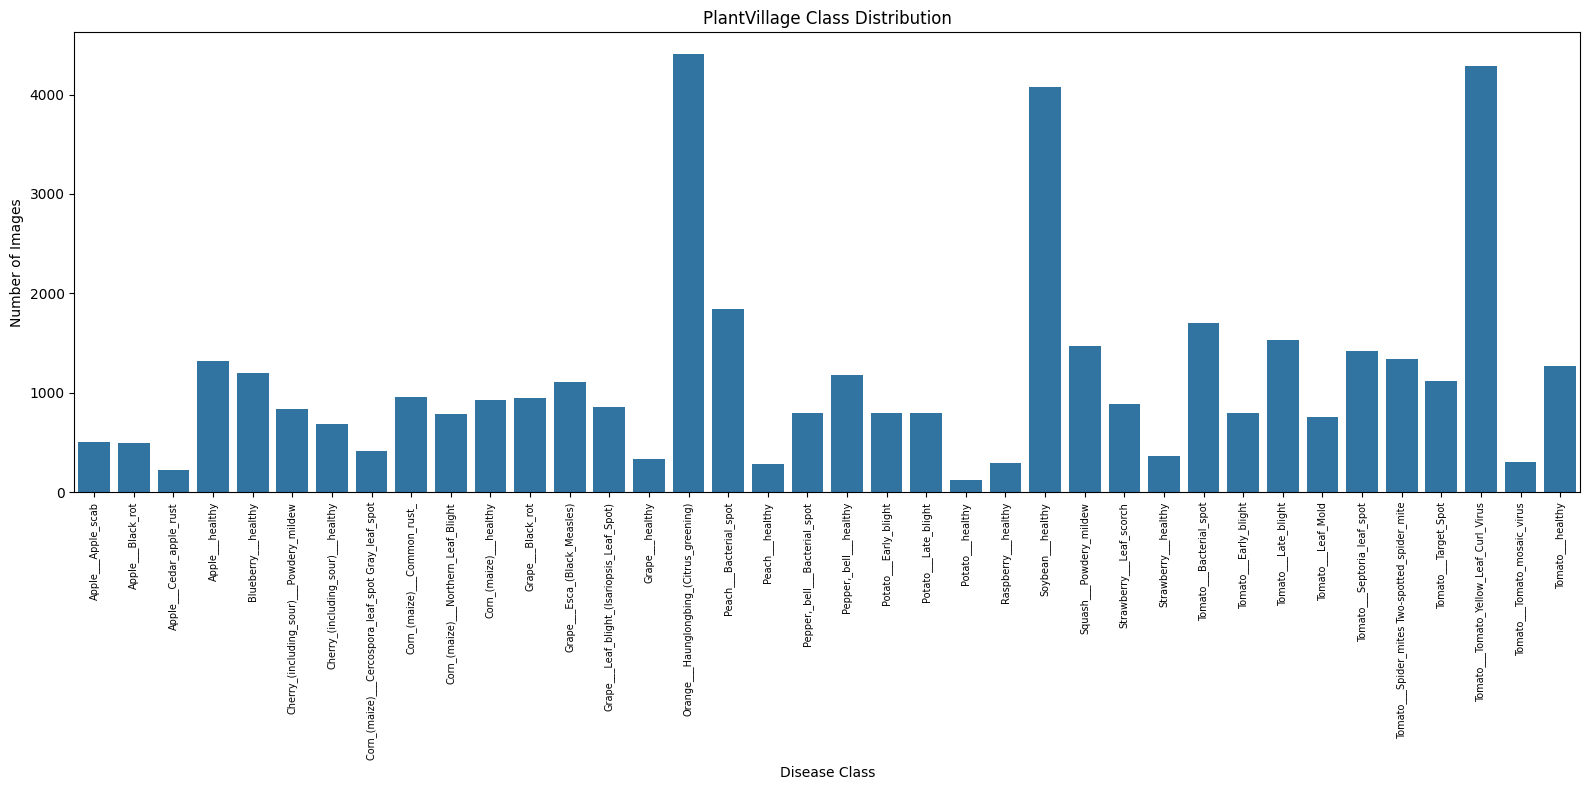

In [27]:

plt.figure(figsize=(16, 8))

sns.barplot(
    data=class_distribution,
    x="Class Name",
    y="Image Count"
)

plt.title("PlantVillage Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()

plt.savefig(
    "/content/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:

train_df, remaining_df = train_test_split(
    image_df,
    test_size=0.30,
    stratify=image_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    remaining_df,
    test_size=0.50,
    stratify=remaining_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print(
    "Total:",
    len(train_df) + len(val_df) + len(test_df)
)

Training images: 30410
Validation images: 6517
Testing images: 6517
Total: 43444


In [29]:

train_df.to_csv(
    "/content/train_split.csv",
    index=False
)

val_df.to_csv(
    "/content/validation_split.csv",
    index=False
)

test_df.to_csv(
    "/content/test_split.csv",
    index=False
)

print("Dataset split files saved")

Dataset split files saved


In [30]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),
    tf.keras.layers.RandomRotation(
        0.10
    ),
    tf.keras.layers.RandomZoom(
        0.10
    ),
    tf.keras.layers.RandomContrast(
        0.10
    ),
    tf.keras.layers.RandomBrightness(
        0.10
    )
])

preprocess_input = (
    tf.keras.applications.mobilenet_v2.preprocess_input
)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [31]:

def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label


def preprocess_train(filepath, label):
    image, label = load_image(
        filepath,
        label
    )

    image = data_augmentation(
        image,
        training=True
    )

    image = preprocess_input(image)

    return image, label


def preprocess_eval(filepath, label):
    image, label = load_image(
        filepath,
        label
    )

    image = preprocess_input(image)

    return image, label

In [32]:

def create_dataset(
    dataframe,
    training=False
):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

        dataset = dataset.map(
            preprocess_train,
            num_parallel_calls=AUTOTUNE
        )
    else:
        dataset = dataset.map(
            preprocess_eval,
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(
        BATCH_SIZE
    ).prefetch(AUTOTUNE)

    return dataset


train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

print("Training dataset created")
print("Validation dataset created")
print("Testing dataset created")

Training dataset created
Validation dataset created
Testing dataset created


In [33]:

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int64'>


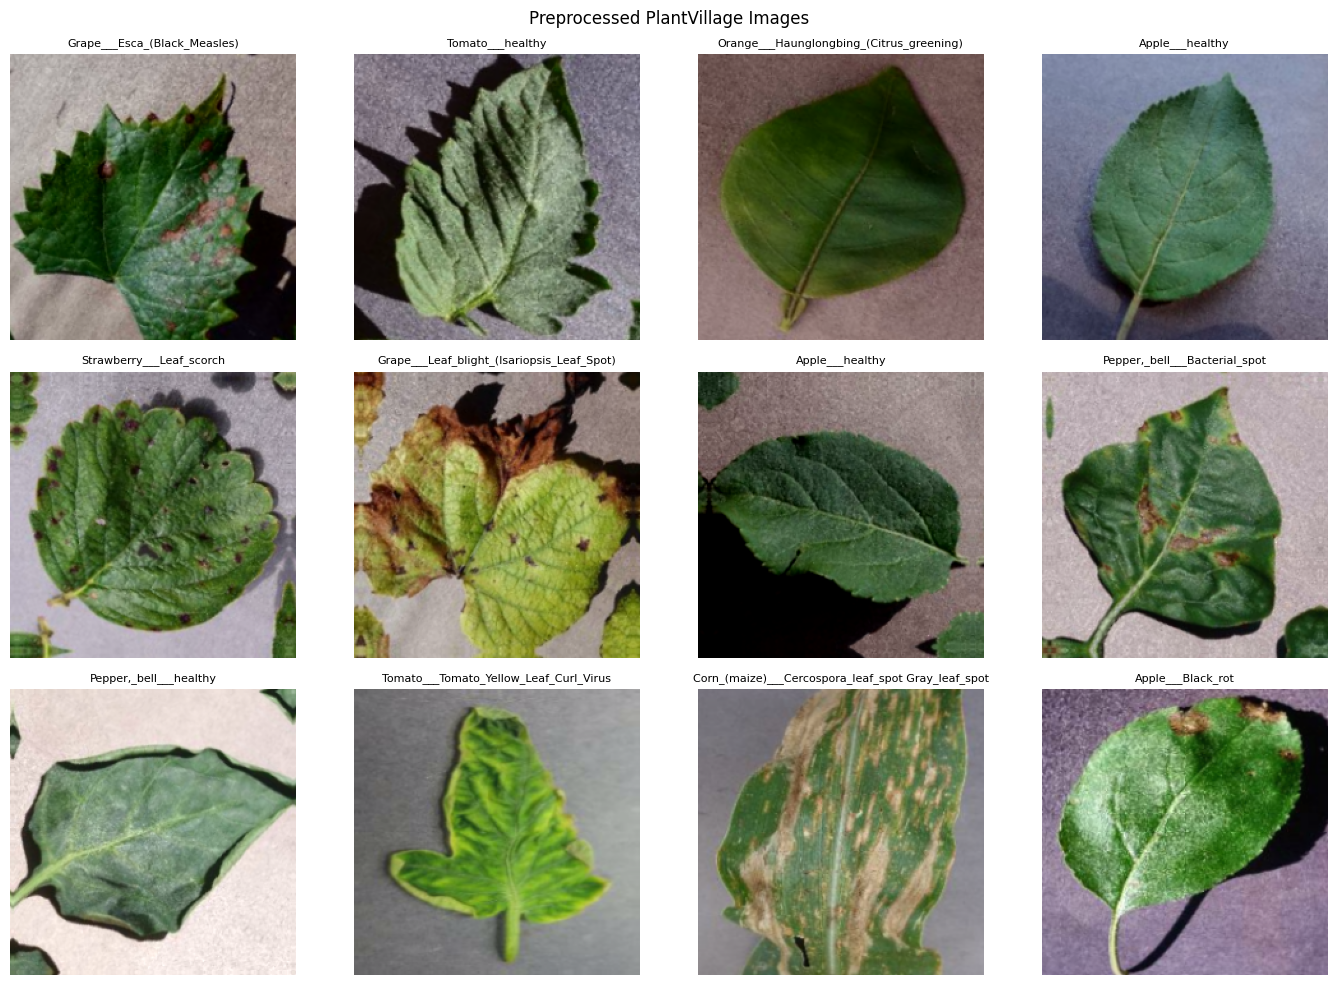

In [34]:

images, labels = next(iter(train_ds))

plt.figure(figsize=(14, 10))

for i in range(min(12, images.shape[0])):
    plt.subplot(3, 4, i + 1)

    display_image = (
        (images[i].numpy() + 1.0) * 127.5
    )

    display_image = np.clip(
        display_image,
        0,
        255
    ).astype(np.uint8)

    plt.imshow(display_image)

    plt.title(
        class_names[labels[i].numpy()],
        fontsize=8
    )

    plt.axis("off")

plt.suptitle(
    "Preprocessed PlantVillage Images"
)

plt.tight_layout()

plt.savefig(
    "/content/preprocessed_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [37]:

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint_path = (
    "/content/best_mobilenetv2.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

print("Callbacks configured")

Callbacks configured


In [38]:

EPOCHS_HEAD = 10

start_time = time.time()

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)

head_training_time = (
    time.time() - start_time
)

print(
    f"Training time: "
    f"{head_training_time / 60:.2f} minutes"
)

Epoch 1/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 381s 381ms/step - accuracy: 0.8296 - loss: 0.6235 - val_accuracy: 0.9170 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 2/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 334s 352ms/step - accuracy: 0.9161 - loss: 0.2703 - val_accuracy: 0.9265 - val_loss: 0.2281 - learning_rate: 0.0010
Epoch 3/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 392s 362ms/step - accuracy: 0.9272 - loss: 0.2284 - val_accuracy: 0.9354 - val_loss: 0.2051 - learning_rate: 0.0010
Epoch 4/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 344s 362ms/step - accuracy: 0.9334 - loss: 0.2020 - val_accuracy: 0.9446 - val_loss: 0.1738 - learning_rate: 0.0010
Epoch 5/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 377s 357ms/step - accuracy: 0.9396 - loss: 0.1884 - val_accuracy: 0.9441 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 6/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 381s 356ms/step - accuracy: 0.9411 - loss: 0.1785 - val_accuracy: 0.9464 - val_loss: 0.1563 - learning_rate: 0.0010
Epoch 7/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 338s 355ms/step - accura

In [39]:

base_model.trainable = True

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

print(
    "Trainable parameters:",
    sum(
        np.prod(layer.shape)
        for layer in model.trainable_weights
    )
)

Trainable parameters: 1888294


In [40]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled")

Model recompiled


In [41]:

EPOCHS_FINE = 10

start_time = time.time()

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)

fine_training_time = (
    time.time() - start_time
)

print(
    f"Fine-tuning time: "
    f"{fine_training_time / 60:.2f} minutes"
)

Epoch 1/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 400s 404ms/step - accuracy: 0.9556 - loss: 0.1325 - val_accuracy: 0.9604 - val_loss: 0.1232 - learning_rate: 1.0000e-05
Epoch 2/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 360s 378ms/step - accuracy: 0.9644 - loss: 0.1052 - val_accuracy: 0.9615 - val_loss: 0.1260 - learning_rate: 1.0000e-05
Epoch 3/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 388s 385ms/step - accuracy: 0.9701 - loss: 0.0863 - val_accuracy: 0.9673 - val_loss: 0.1106 - learning_rate: 1.0000e-05
Epoch 4/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 361s 380ms/step - accuracy: 0.9716 - loss: 0.0798 - val_accuracy: 0.9744 - val_loss: 0.0813 - learning_rate: 1.0000e-05
Epoch 5/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 362s 381ms/step - accuracy: 0.9757 - loss: 0.0682 - val_accuracy: 0.9708 - val_loss: 0.0927 - learning_rate: 1.0000e-05
Epoch 6/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 358s 376ms/step - accuracy: 0.9777 - loss: 0.0624 - val_accuracy: 0.9759 - val_loss: 0.0818 - learning_rate: 1.0000e-05
Epoch 7/10
951/951 ━━━━━━━━━━━━━━━━━━━━ 

In [42]:

def combine_histories(history_a, history_b):
    combined = {}

    for key in history_a.history:
        combined[key] = (
            history_a.history[key]
            + history_b.history.get(key, [])
        )

    return combined


combined_history = combine_histories(
    history_head,
    history_fine
)

print(
    "Total epochs:",
    len(combined_history["loss"])
)

Total epochs: 20


In [43]:

def combine_histories(history_a, history_b):
    combined = {}

    for key in history_a.history:
        combined[key] = (
            history_a.history[key]
            + history_b.history.get(key, [])
        )

    return combined


combined_history = combine_histories(
    history_head,
    history_fine
)

print(
    "Total epochs:",
    len(combined_history["loss"])
)

Total epochs: 20


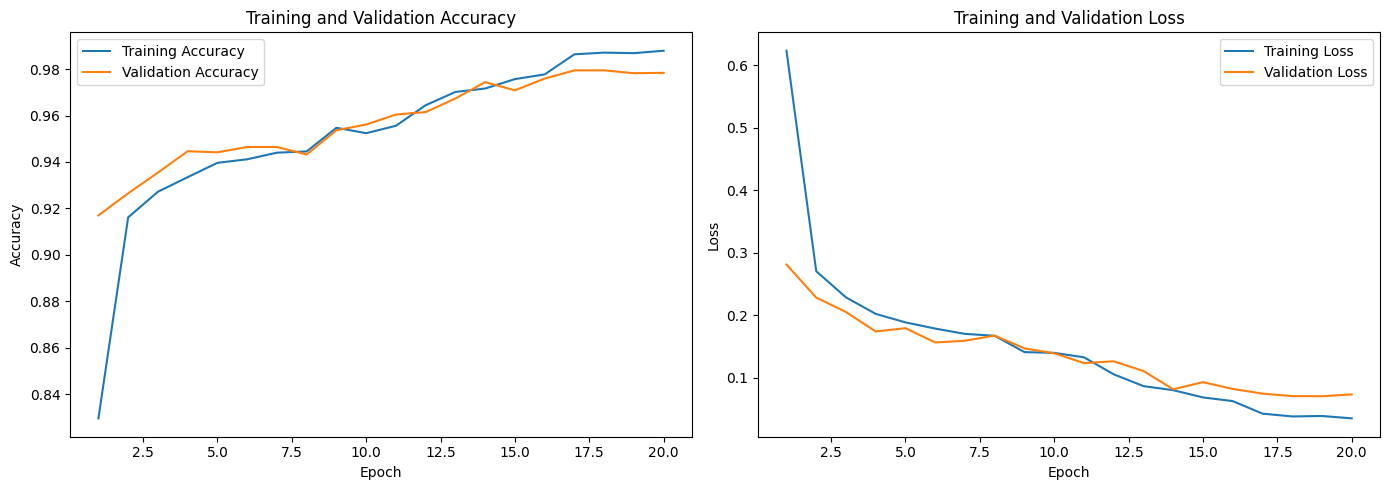

In [44]:

epochs_range = range(
    1,
    len(combined_history["loss"]) + 1
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    combined_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    combined_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    combined_history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    combined_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/training_validation_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9776 - loss: 0.0713
Test loss: 0.0713
Test accuracy: 0.9776


In [46]:

y_true = []
y_pred = []
y_probabilities = []

for images, labels in test_ds:

    probabilities = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_probabilities.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probabilities = np.array(y_probabilities)

print("Test samples:", len(y_true))
print("Prediction shape:", y_probabilities.shape)

Test samples: 6517
Prediction shape: (6517, 38)


In [47]:

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1 Score"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print(metrics_table.to_string(index=False))

            Metric    Value
          Accuracy 0.977597
Weighted Precision 0.978657
   Weighted Recall 0.977597
 Weighted F1 Score 0.977589


In [48]:

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

classification_df = pd.DataFrame(
    report
).transpose()

print(
    classification_df.to_string()
)

                                                    precision    recall  f1-score      support
Apple___Apple_scab                                   0.986842  1.000000  0.993377    75.000000
Apple___Black_rot                                    1.000000  1.000000  1.000000    74.000000
Apple___Cedar_apple_rust                             1.000000  1.000000  1.000000    33.000000
Apple___healthy                                      1.000000  0.989899  0.994924   198.000000
Blueberry___healthy                                  1.000000  0.988950  0.994444   181.000000
Cherry_(including_sour)___Powdery_mildew             0.992188  1.000000  0.996078   127.000000
Cherry_(including_sour)___healthy                    1.000000  1.000000  1.000000   102.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   0.805556  0.935484  0.865672    62.000000
Corn_(maize)___Common_rust_                          0.986207  1.000000  0.993056   143.000000
Corn_(maize)___Northern_Leaf_Blight               

In [49]:

metrics_table.to_csv(
    "/content/mobilenetv2_metrics.csv",
    index=False
)

classification_df.to_csv(
    "/content/mobilenetv2_classification_report.csv"
)

print("Evaluation tables saved")

Evaluation tables saved


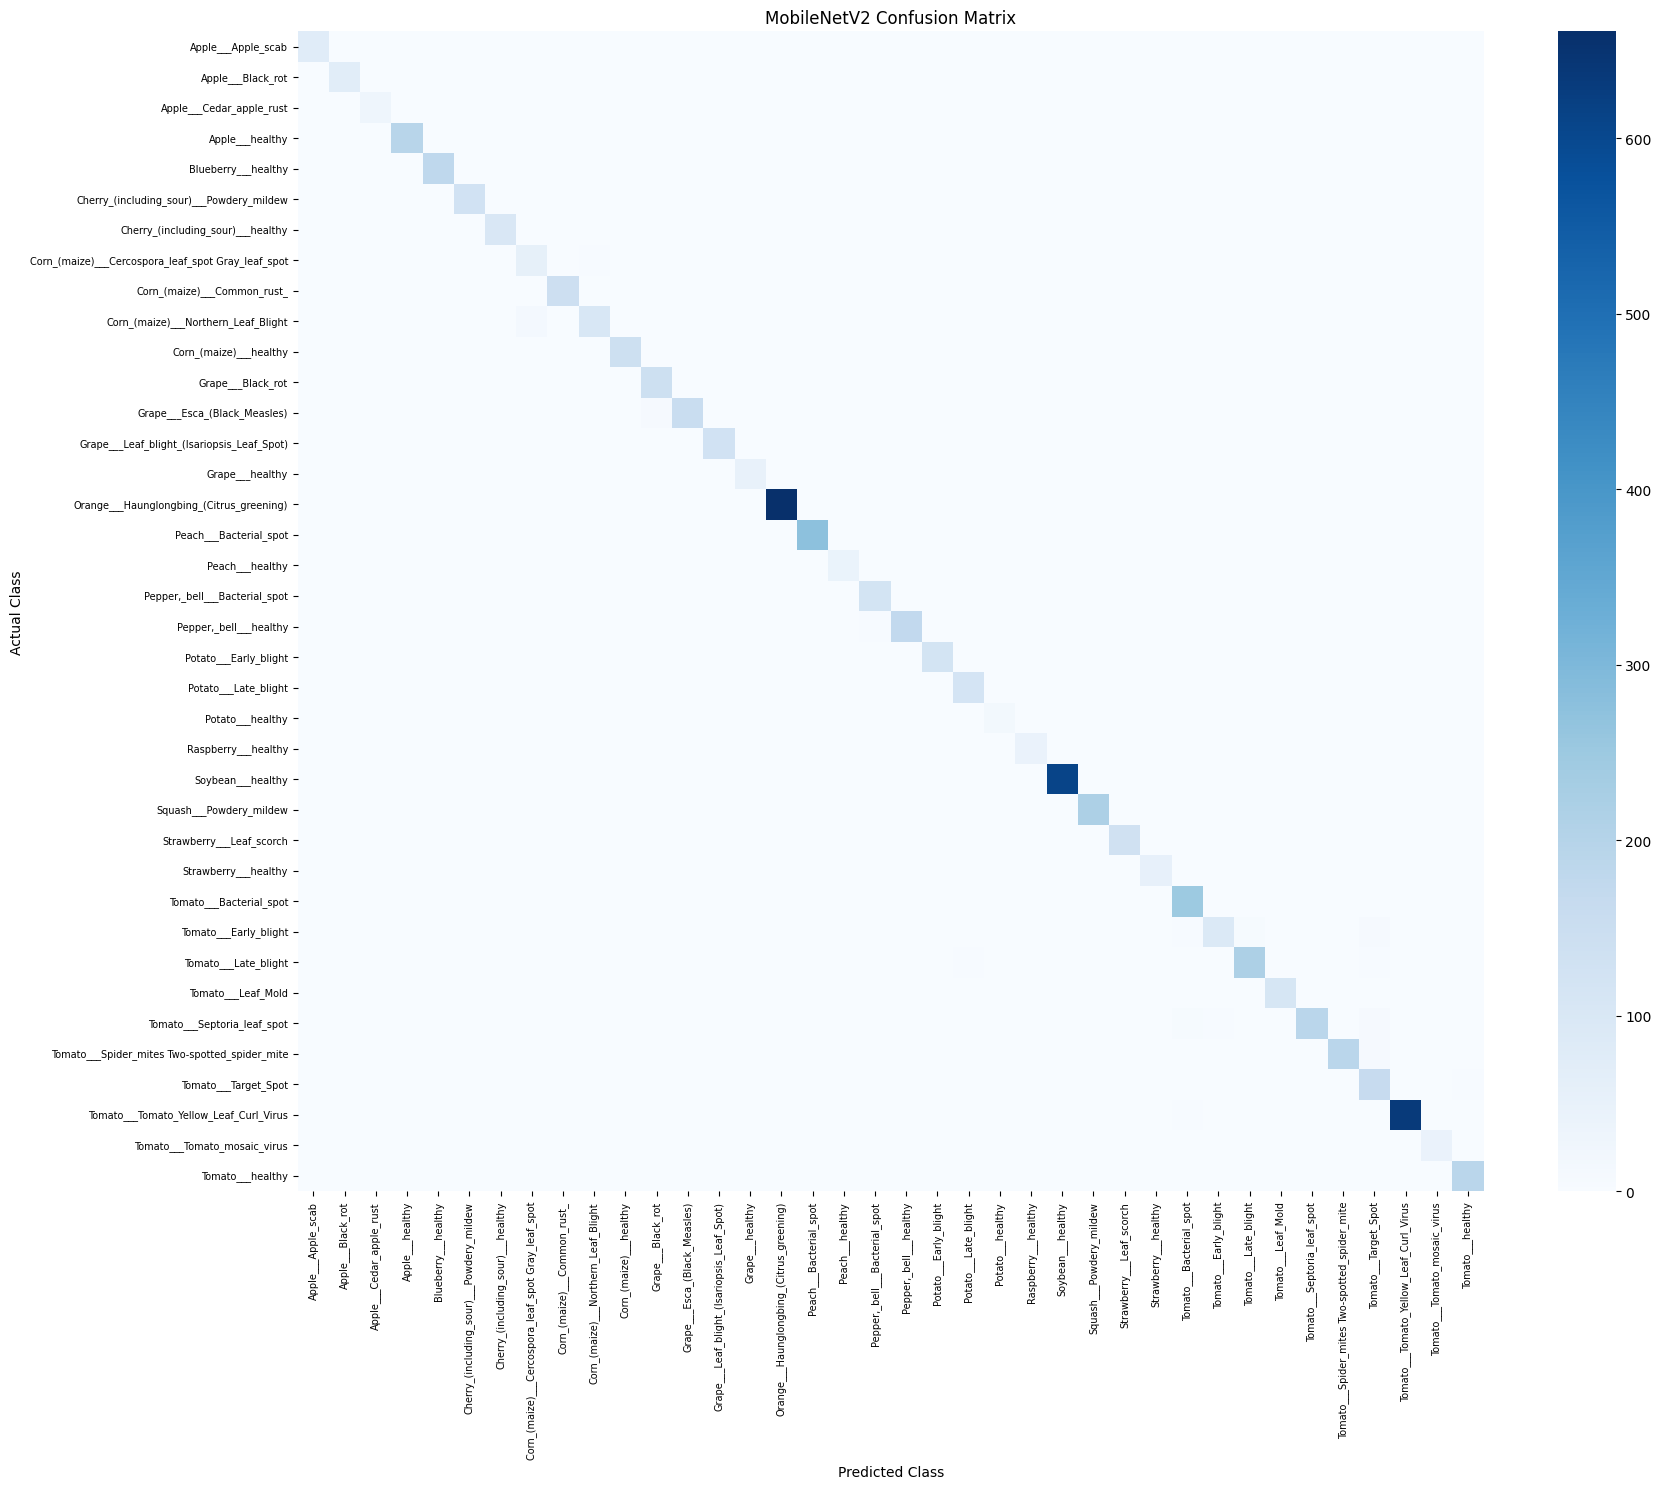

In [50]:

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES)
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)

plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    "/content/confusion_matrix.csv"
)

print("Confusion matrix saved")

Confusion matrix saved


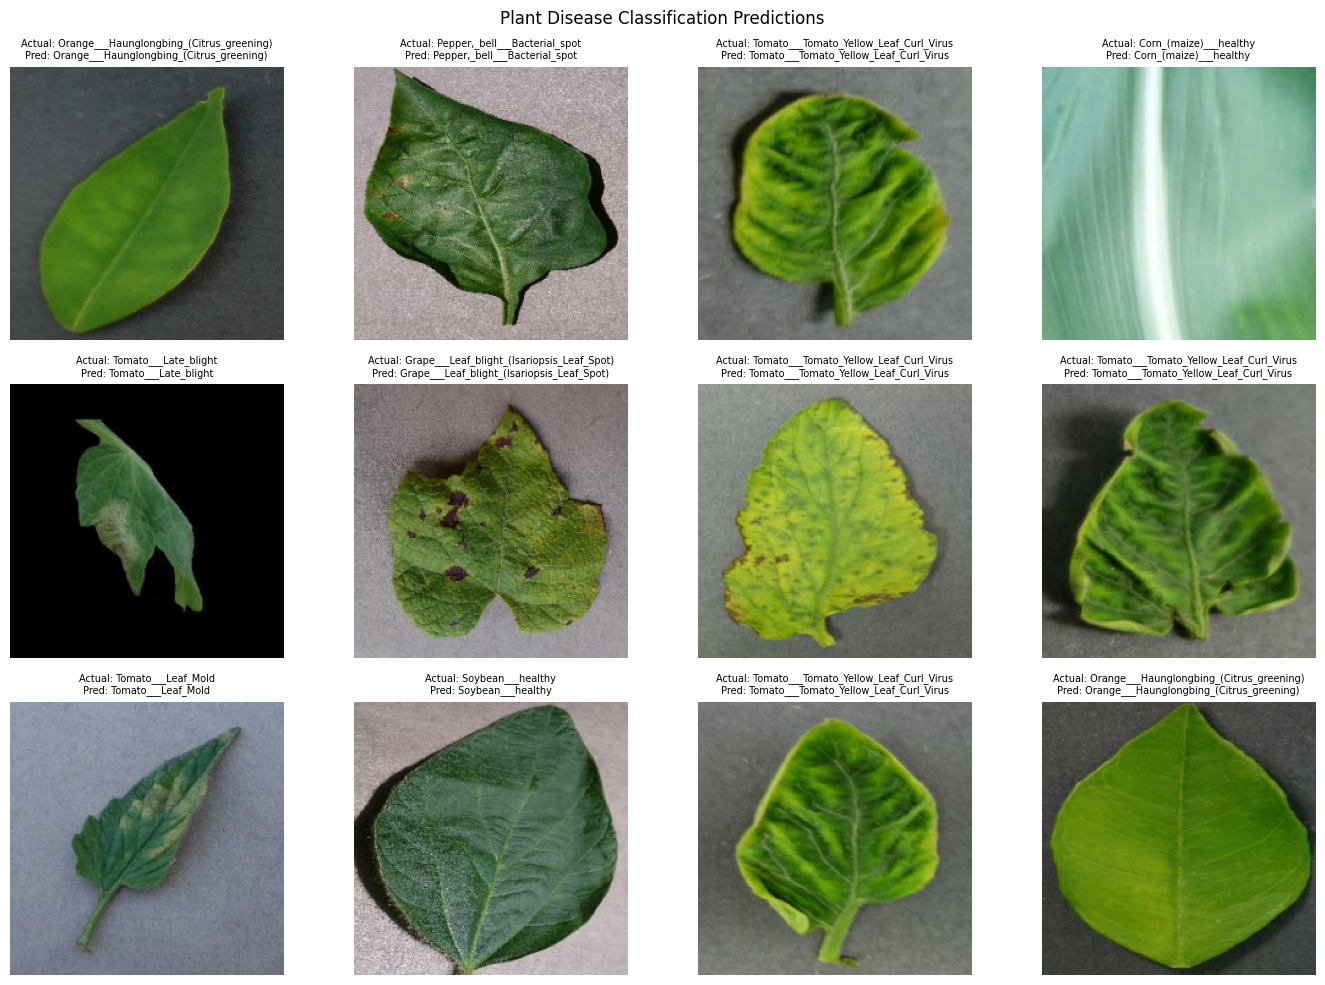

In [52]:

sample_images, sample_labels = next(iter(test_ds))

sample_probabilities = model.predict(
    sample_images,
    verbose=0
)

sample_predictions = np.argmax(
    sample_probabilities,
    axis=1
)

plt.figure(figsize=(14, 10))

for i in range(min(12, len(sample_images))):

    plt.subplot(3, 4, i + 1)

    display_image = (
        (sample_images[i].numpy() + 1.0) * 127.5
    )

    display_image = np.clip(
        display_image,
        0,
        255
    ).astype(np.uint8)

    actual = class_names[
        sample_labels[i].numpy()
    ]

    predicted = class_names[
        sample_predictions[i]
    ]

    plt.imshow(display_image)

    plt.title(
        f"Actual: {actual}\nPred: {predicted}",
        fontsize=7
    )

    plt.axis("off")

plt.suptitle(
    "Plant Disease Classification Predictions"
)

plt.tight_layout()

plt.savefig(
    "/content/prediction_visualizations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:

def create_robustness_dataset(
    dataframe,
    mode
):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    def transform(filepath, label):
        image, label = load_image(
            filepath,
            label
        )

        if mode == "brightness":
            image = tf.image.adjust_brightness(
                image,
                delta=35.0
            )

        elif mode == "contrast":
            image = tf.image.adjust_contrast(
                image,
                contrast_factor=1.5
            )

        elif mode == "low_resolution":
            image = tf.image.resize(
                image,
                (112, 112)
            )

            image = tf.image.resize(
                image,
                IMG_SIZE
            )

        image = tf.clip_by_value(
            image,
            0.0,
            255.0
        )

        image = preprocess_input(image)

        return image, label

    dataset = dataset.map(
        transform,
        num_parallel_calls=AUTOTUNE
    )

    return dataset.batch(
        BATCH_SIZE
    ).prefetch(AUTOTUNE)

In [54]:

robustness_results = []

for mode in [
    "brightness",
    "contrast",
    "low_resolution"
]:

    robustness_ds = create_robustness_dataset(
        test_df,
        mode
    )

    loss, accuracy_value = model.evaluate(
        robustness_ds,
        verbose=0
    )

    robustness_results.append({
        "Condition": mode,
        "Loss": loss,
        "Accuracy": accuracy_value
    })

robustness_df = pd.DataFrame(
    robustness_results
)

print(
    robustness_df.to_string(index=False)
)

robustness_df.to_csv(
    "/content/robustness_results.csv",
    index=False
)

     Condition     Loss  Accuracy
    brightness 0.074905  0.977597
      contrast 0.116181  0.962713
low_resolution 0.104649  0.965628


In [55]:

sample_images, sample_labels = next(iter(test_ds))

_ = model(
    sample_images,
    training=False
)

start_time = time.perf_counter()

_ = model(
    sample_images,
    training=False
)

elapsed_time = time.perf_counter() - start_time

batch_size_actual = sample_images.shape[0]

average_time_per_image = (
    elapsed_time / batch_size_actual
)

print("Batch size:", batch_size_actual)

print(
    f"Batch inference time: "
    f"{elapsed_time * 1000:.2f} ms"
)

print(
    f"Average time per image: "
    f"{average_time_per_image * 1000:.2f} ms"
)

Batch size: 32
Batch inference time: 350.53 ms
Average time per image: 10.95 ms


In [56]:

model_path = (
    "/content/mobilenetv2_crop_disease.keras"
)

model.save(model_path)

file_size_mb = (
    os.path.getsize(model_path)
    / (1024 * 1024)
)

total_parameters = model.count_params()

print("Model saved:", model_path)
print("Total parameters:", total_parameters)
print(f"Model size: {file_size_mb:.2f} MB")

Model saved: /content/mobilenetv2_crop_disease.keras
Total parameters: 2306662
Model size: 23.78 MB


In [57]:

history_df = pd.DataFrame(
    combined_history
)

history_df.to_csv(
    "/content/training_history.csv",
    index=False
)

summary_data = {
    "Model": "MobileNetV2",
    "Number of Classes": NUM_CLASSES,
    "Input Size": "224x224x3",
    "Training Images": len(train_df),
    "Validation Images": len(val_df),
    "Test Images": len(test_df),
    "Test Accuracy": accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1": f1,
    "Total Parameters": total_parameters,
    "Model Size (MB)": file_size_mb,
    "Head Training Time (Minutes)": (
        head_training_time / 60
    ),
    "Fine Tuning Time (Minutes)": (
        fine_training_time / 60
    )
}

summary_df = pd.DataFrame(
    list(summary_data.items()),
    columns=["Metric", "Value"]
)

print(
    summary_df.to_string(index=False)
)

summary_df.to_csv(
    "/content/final_summary.csv",
    index=False
)

                      Metric       Value
                       Model MobileNetV2
           Number of Classes          38
                  Input Size   224x224x3
             Training Images       30410
           Validation Images        6517
                 Test Images        6517
               Test Accuracy    0.977597
          Weighted Precision    0.978657
             Weighted Recall    0.977597
                 Weighted F1    0.977589
            Total Parameters     2306662
             Model Size (MB)   23.780157
Head Training Time (Minutes)   60.619895
  Fine Tuning Time (Minutes)   61.916635


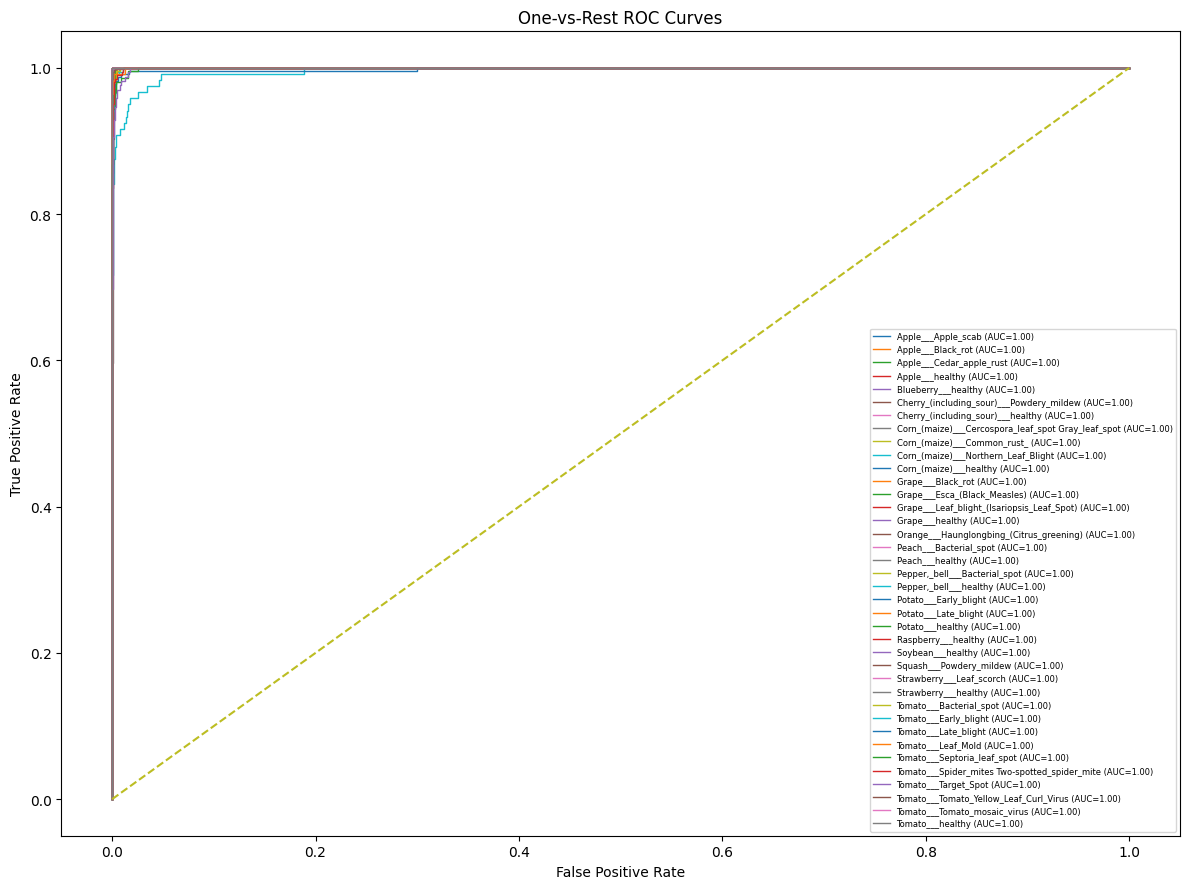

In [58]:

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_onehot = label_binarize(
    y_true,
    classes=range(NUM_CLASSES)
)

plt.figure(figsize=(12, 9))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_onehot[:, i],
        y_probabilities[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=1,
        label=f"{class_names[i]} (AUC={roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")

plt.legend(
    loc="lower right",
    fontsize=6
)

plt.tight_layout()

plt.savefig(
    "/content/roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:

output_files = [
    "/content/best_mobilenetv2.keras",
    "/content/mobilenetv2_crop_disease.keras",
    "/content/mobilenetv2_metrics.csv",
    "/content/mobilenetv2_classification_report.csv",
    "/content/training_history.csv",
    "/content/robustness_results.csv",
    "/content/final_summary.csv",
    "/content/confusion_matrix.csv",
    "/content/class_distribution.png",
    "/content/preprocessed_samples.png",
    "/content/training_validation_curves.png",
    "/content/confusion_matrix.png",
    "/content/prediction_visualizations.png",
    "/content/roc_curves.png",
    "/content/train_split.csv",
    "/content/validation_split.csv",
    "/content/test_split.csv"
]

existing_files = [
    file_path
    for file_path in output_files
    if os.path.exists(file_path)
]

zip_path = (
    "/content/drone_vision_task1_outputs.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for file_path in existing_files:
        zip_file.write(
            file_path,
            arcname=os.path.basename(file_path)
        )

print("ZIP package created")
print("Files included:", len(existing_files))
print("Location:", zip_path)

ZIP package created
Files included: 17
Location: /content/drone_vision_task1_outputs.zip


In [60]:

from google.colab import files

files.download(
    "/content/drone_vision_task1_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>